In [1]:
# import libraries
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path(r"C:\Users\Admin\lungprints")
DATA_DIR = PROJECT_ROOT / "data" / "chest_xray"
FIG_DIR = PROJECT_ROOT / "results" / "figures"


In [4]:
# class distribution table
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

rows = []
for split in splits:
    for cls in classes:
        files = list((DATA_DIR / split / cls).glob("*"))
        rows.append({"split": split, "class": cls, "count": len(files)})

df = pd.DataFrame(rows)
pivot = df.pivot(index="split", columns="class", values="count")
pivot["total"] = pivot.sum(axis=1)
pivot["pneumonia_ratio"] = (pivot["PNEUMONIA"] / pivot["total"]).round(3)
print(pivot)

class  NORMAL  PNEUMONIA  total  pneumonia_ratio
split                                           
test        0          0      0              NaN
train       0          0      0              NaN
val         0          0      0              NaN


In [5]:
from pathlib import Path

BASE = Path(r"C:\Users\Admin\lungprints\data\pneumonia")

# Case A: BASE contains train/val/test directly
# Case B: BASE contains chest_xray/ which contains train/val/test

def find_data_root(base):
    # If base itself has train/val/test, use base
    if all((base / s).exists() for s in ["train", "val", "test"]):
        return base
    # If base has a single subfolder with train/val/test, use that
    for sub in base.iterdir():
        if sub.is_dir() and all((sub / s).exists() for s in ["train", "val", "test"]):
            return sub
    return None

DATA_DIR = find_data_root(BASE)
print("Resolved DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists() if DATA_DIR else False)

# Check what's inside train/NORMAL
sample_folder = DATA_DIR / "train" / "NORMAL"
files = list(sample_folder.iterdir())[:5]
print("First 5 files in train/NORMAL:")
for f in files:
    print("  ", f.name, "| suffix:", f.suffix)

Resolved DATA_DIR: C:\Users\Admin\lungprints\data\pneumonia\chest_xray
Exists: True
First 5 files in train/NORMAL:
   IM-0115-0001.jpeg | suffix: .jpeg
   IM-0117-0001.jpeg | suffix: .jpeg
   IM-0119-0001.jpeg | suffix: .jpeg
   IM-0122-0001.jpeg | suffix: .jpeg
   IM-0125-0001.jpeg | suffix: .jpeg


In [6]:
# bar charts
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(splits))
w = 0.35
ax.bar(x - w/2, pivot["NORMAL"], w, label="NORMAL", color="#4C9F70")
ax.bar(x + w/2, pivot["PNEUMONIA"], w, label="PNEUMONIA", color="#C0504D")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Images")
ax.set_title("Class distribution per split")
ax.legend()
for i, s in enumerate(splits):
    ax.text(i - w/2, pivot.loc[s, "NORMAL"] + 50, str(pivot.loc[s, "NORMAL"]), ha="center", fontsize=9)
    ax.text(i + w/2, pivot.loc[s, "PNEUMONIA"] + 50, str(pivot.loc[s, "PNEUMONIA"]), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14328\1704126295.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


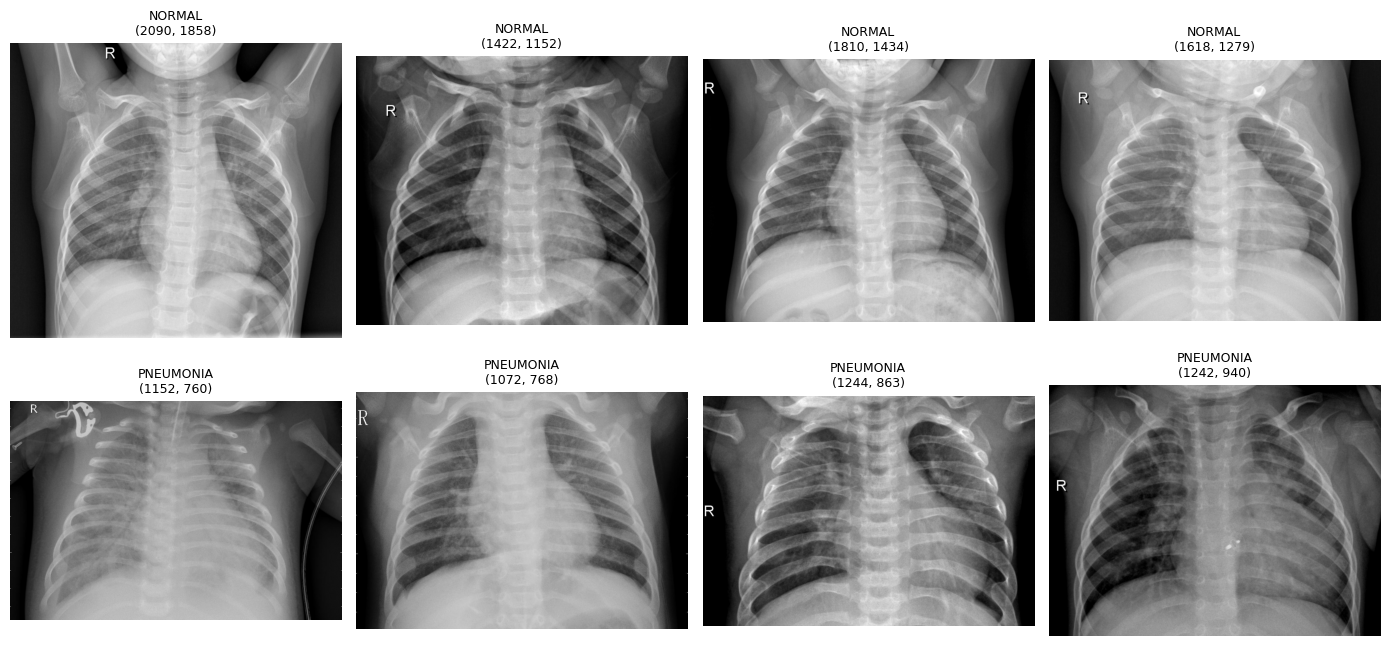

In [7]:
# sample inages
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, cls in enumerate(classes):
    files = list((DATA_DIR / "train" / cls).glob("*"))[:4]
    for j, f in enumerate(files):
        img = Image.open(f).convert("L")
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].set_title(f"{cls}\n{img.size}", fontsize=9)
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_sample_images.png", dpi=150)
plt.show()

In [8]:
# image size stats
sizes = []
for cls in classes:
    for f in list((DATA_DIR / "train" / cls).glob("*"))[:300]:
        sizes.append(Image.open(f).size)

sizes = np.array(sizes)
print("Width  — min:", sizes[:,0].min(), " max:", sizes[:,0].max(), " mean:", round(sizes[:,0].mean(),1))
print("Height — min:", sizes[:,1].min(), " max:", sizes[:,1].max(), " mean:", round(sizes[:,1].mean(),1))
print("Top 5 shapes:", Counter(map(tuple, sizes)).most_common(5))


Width  — min: 502  max: 2538  mean: 1453.4
Height — min: 307  max: 2411  mean: 1100.3
Top 5 shapes: [((np.int64(1472), np.int64(1171)), 2), ((np.int64(912), np.int64(480)), 2), ((np.int64(1088), np.int64(712)), 2), ((np.int64(1136), np.int64(840)), 2), ((np.int64(1467), np.int64(1044)), 2)]
